In [1]:
import pandas as pd

# Load the dataset
file_path = "Downloads/Dataset .csv"
df = pd.read_csv(file_path)

# Display basic info
print("Dataset Loaded Successfully!")
print("\nColumn Names:", df.columns)

# Check if latitude and longitude columns exist
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    print("\nSample Location Data:\n", df[['Latitude', 'Longitude']].head())
else:
    print("\nLatitude and Longitude columns not found in the dataset.")


Dataset Loaded Successfully!

Column Names: Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Sample Location Data:
     Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508


In [3]:
!pip install folium


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install folium 


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import folium
from folium.plugins import HeatMap

# Create a base map centered at an approximate location
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=10)

# Add restaurant locations as markers
for index, row in df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row.get('Restaurant Name', 'Unknown'),
        icon=folium.Icon(color="blue", icon="cutlery")
    ).add_to(m)

# Save and display the map
m.save("restaurant_map.html")
print("Map saved as restaurant_map.html")


Map saved as restaurant_map.html


In [6]:
# Create a heatmap of restaurant density
m_heatmap = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=10)

# Convert location data to list
heat_data = df[['Latitude', 'Longitude']].dropna().values.tolist()

# Add heatmap layer
HeatMap(heat_data).add_to(m_heatmap)

# Save and display the heatmap
m_heatmap.save("restaurant_heatmap.html")
print("Heatmap saved as restaurant_heatmap.html")


Heatmap saved as restaurant_heatmap.html


C:\Users\Aditi\AppData\Local\Temp\ipykernel_4708\1877672627.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")


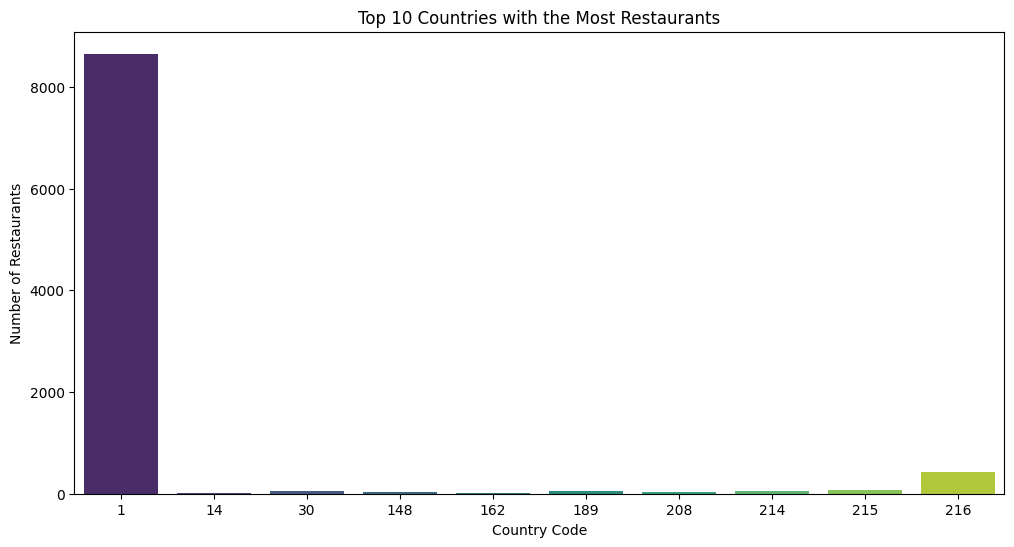

C:\Users\Aditi\AppData\Local\Temp\ipykernel_4708\1877672627.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette="coolwarm")


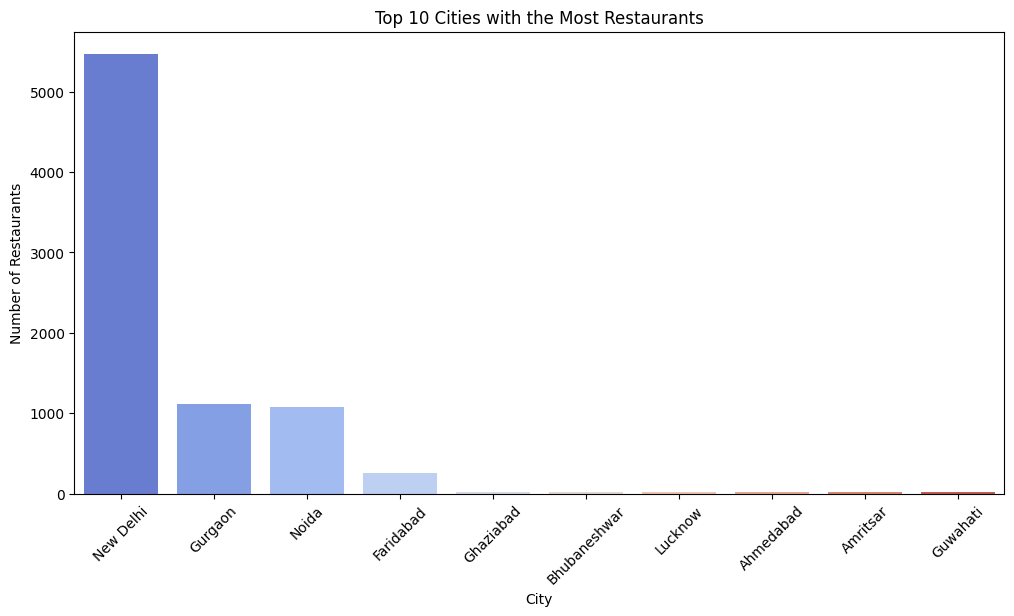

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 countries with most restaurants
plt.figure(figsize=(12, 6))
top_countries = df["Country Code"].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Countries with the Most Restaurants")
plt.show()

# Top 10 cities with most restaurants
plt.figure(figsize=(12, 6))
top_cities = df["City"].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette="coolwarm")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Cities with the Most Restaurants")
plt.xticks(rotation=45)
plt.show()

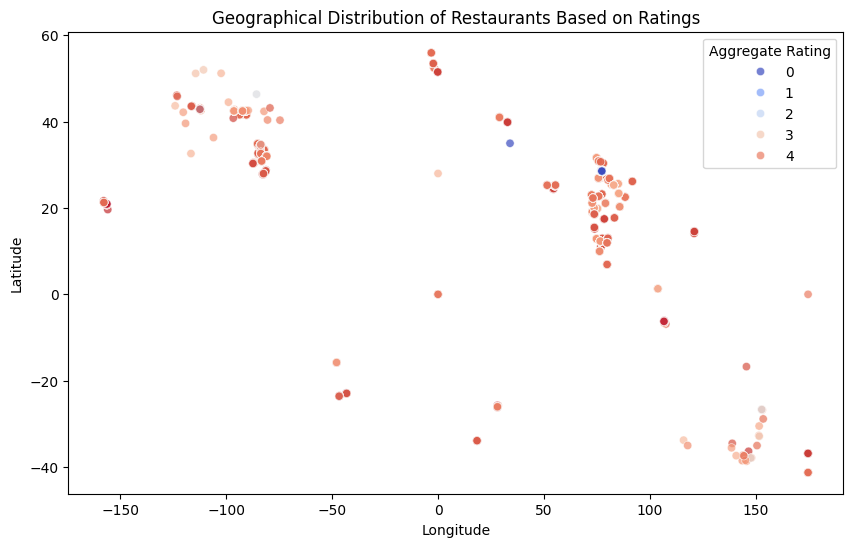


Correlation Between Location and Ratings:
                   Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


In [8]:
import numpy as np

# Scatter plot of Latitude vs Aggregate Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], hue=df["Aggregate rating"], palette="coolwarm", alpha=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Restaurants Based on Ratings")
plt.legend(title="Aggregate Rating")
plt.show()

# Correlation check
correlation = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print("\nCorrelation Between Location and Ratings:\n", correlation)